# Lecture 2: Data Preparation in Finance
---
Data preparation is the unglamorous but absolutely essential backbone of any successful Machine Learning project, especially in Quantitative Finance. In this extensive 3-week module, we will explore the three critical pillars of preparing robust datasets:
1. **Data Cleaning** (Handling Missing Values and Outliers)
2. **Data Transformation** (Scaling, Encoding, and Imbalanced Data)
3. **Feature Selection** (Filtering the signal from the noise)


## Part 1: Data Cleaning (Week 3)
---
Financial data is notoriously messy. Asset prices can have missing days due to trading holidays, alternative data sources can have structural gaps, and flash crashes can create massive outliers.


### 1.1 Understanding Missing Data Mechanisms
Before we can treat missing data, we must understand *why* it is missing.
* **MCAR (Missing Completely At Random):** The probability of being missing is the same for all observations. (e.g., a sensor randomly failing).
* **MAR (Missing At Random):** The probability of being missing depends on observed data. (e.g., older users might be less likely to fill out a tech survey, but once we condition on age, the missingness is random).
* **MNAR (Missing Not At Random):** The probability of being missing depends on the unobserved value itself. (e.g., people with extremely high incomes might refuse to disclose their income).

> **Important:** In finance, MNAR is very common! For example, an illiquid asset might not have a price on a given day *because* it is illiquid.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Let's generate a synthetic financial dataset with missing values
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
df = pd.DataFrame({
    'Date': dates,
    'Stock_A_Price': 100 + np.random.randn(100).cumsum(),
    'Stock_B_Price': 50 + np.random.randn(100).cumsum(),
    'Volume': np.random.randint(1000, 10000, size=100),
    'Sector': np.random.choice(['Tech', 'Finance', 'Energy'], size=100)
})

# Introduce some missing values (MCAR)
df.loc[10:15, 'Stock_A_Price'] = np.nan
df.loc[45:50, 'Stock_B_Price'] = np.nan
df.loc[80:85, 'Volume'] = np.nan

# Check missing values
print("Missing Values Summary:")
print(df.isnull().sum())


Missing Values Summary:
Date             0
Stock_A_Price    6
Stock_B_Price    6
Volume           6
Sector           0
dtype: int64


### 1.2 Handling Missing Data

#### Strategy A: Deletion
If the data is MCAR and the proportion of missing data is very small (<5%), we might just drop those rows.
* **Listwise Deletion:** Drop any row containing at least one missing value.


In [2]:
# Listwise deletion
df_dropped = df.dropna()
print(f"Original shape: {df.shape}")
print(f"Shape after dropping: {df_dropped.shape}")


Original shape: (100, 5)
Shape after dropping: (82, 5)


#### Strategy B: Simple Imputation
We replace missing values with a statistical estimate (Mean, Median, Mode).
* **Mean:** Good for normally distributed continuous data. Sensitive to outliers.
* **Median:** Robust to outliers. Ideal for skewed data (like income or returns).
* **Mode:** Used for categorical data.


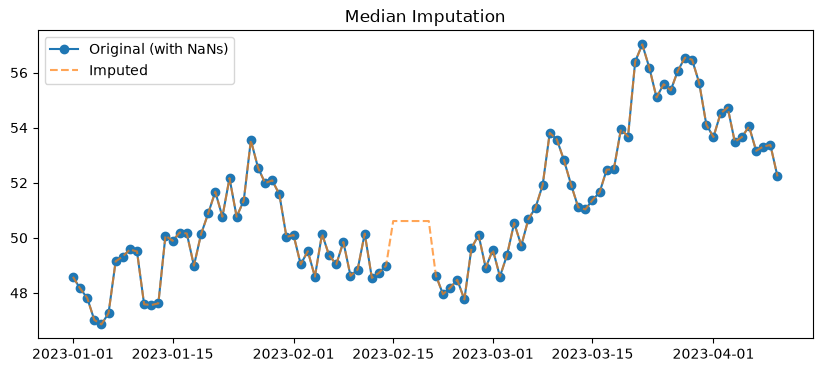

In [3]:
from sklearn.impute import SimpleImputer

# Imputing with Median
imputer = SimpleImputer(strategy='median')
df['Stock_B_Price_Imputed'] = imputer.fit_transform(df[['Stock_B_Price']])

# Visualizing the imputation
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Stock_B_Price'], label='Original (with NaNs)', marker='o')
plt.plot(df['Date'], df['Stock_B_Price_Imputed'], label='Imputed', linestyle='--', alpha=0.7)
plt.legend()
plt.title("Median Imputation")
plt.show()


#### Strategy C: Time-Series Specific Imputation
Financial data is sequential. Replacing a missing stock price with the global mean is a terrible idea! We should use contextual time-series methods.
* **Forward Fill (`ffill`):** Propagate the last valid observation forward. Very common for prices to avoid look-ahead bias.
* **Linear Interpolation:** Draw a straight line between the known points.


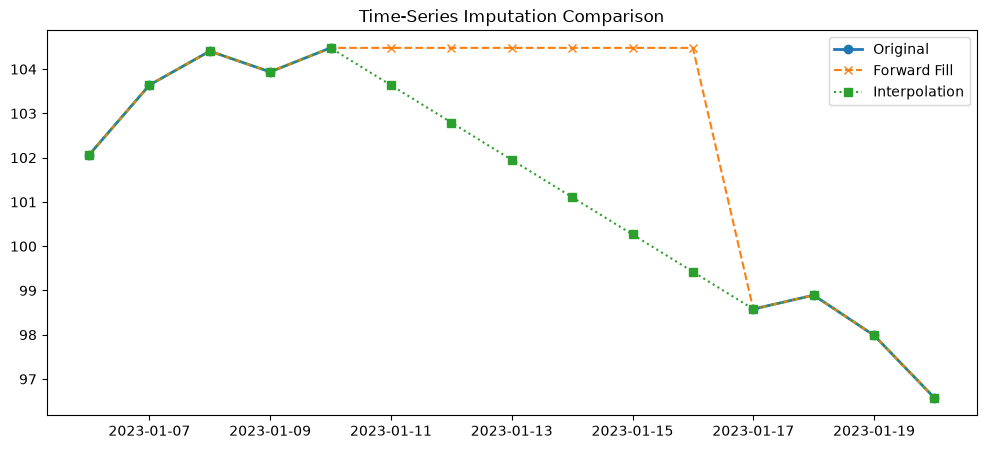

In [4]:
# Forward fill for Stock A
df['Stock_A_ffill'] = df['Stock_A_Price'].fillna(method='ffill')

# Interpolation for Stock A
df['Stock_A_interp'] = df['Stock_A_Price'].interpolate(method='linear')

plt.figure(figsize=(12,5))
plt.plot(df['Date'][5:20], df['Stock_A_Price'][5:20], label='Original', marker='o', linewidth=2)
plt.plot(df['Date'][5:20], df['Stock_A_ffill'][5:20], label='Forward Fill', marker='x', linestyle='--')
plt.plot(df['Date'][5:20], df['Stock_A_interp'][5:20], label='Interpolation', marker='s', linestyle=':')
plt.legend()
plt.title("Time-Series Imputation Comparison")
plt.show()


### 1.3 Handling Outliers
Outliers can destroy the performance of distance-based models (like KNN) or linear models (like Linear Regression).

#### The Z-Score Method
Assuming a normal distribution, ~99.7% of the data lies within 3 standard deviations of the mean.
$$ Z = rac{x - \mu}{\sigma} $$
If $|Z| > 3$, the point is an outlier.


In [5]:
# Introduce an artificial flash crash outlier
df.loc[30, 'Stock_A_Price'] = 10  # Flash crash

mean_a = df['Stock_A_Price'].mean()
std_a = df['Stock_A_Price'].std()
df['Z_Score_A'] = (df['Stock_A_Price'] - mean_a) / std_a

# Find outliers
outliers_z = df[df['Z_Score_A'].abs() > 3]
print("Detected Outliers using Z-Score:")
print(outliers_z[['Date', 'Stock_A_Price', 'Z_Score_A']])


Detected Outliers using Z-Score:
         Date  Stock_A_Price  Z_Score_A
30 2023-01-31           10.0  -8.609141


#### The IQR Method (Robust to Extreme Values)
The Interquartile Range (IQR) is the difference between the 75th percentile ($Q3$) and 25th percentile ($Q1$).
$$ IQR = Q3 - Q1 $$
Lower Bound: $Q1 - 1.5 	imes IQR$
Upper Bound: $Q3 + 1.5 	imes IQR$


In [6]:
Q1 = df['Stock_A_Price'].quantile(0.25)
Q3 = df['Stock_A_Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Stock_A_Price'] < lower_bound) | (df['Stock_A_Price'] > upper_bound)]
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print("Detected Outliers using IQR:")
print(outliers_iqr[['Date', 'Stock_A_Price']])


Lower Bound: 82.16, Upper Bound: 102.95
Detected Outliers using IQR:
         Date  Stock_A_Price
6  2023-01-07     103.640091
7  2023-01-08     104.407525
8  2023-01-09     103.938051
9  2023-01-10     104.480611
30 2023-01-31      10.000000


#### Treating Outliers: Winsorization
Instead of deleting outliers, we often "cap" them at a certain percentile (e.g., 1st and 99th percentile). This is called Winsorization and is standard practice in quantitative finance.


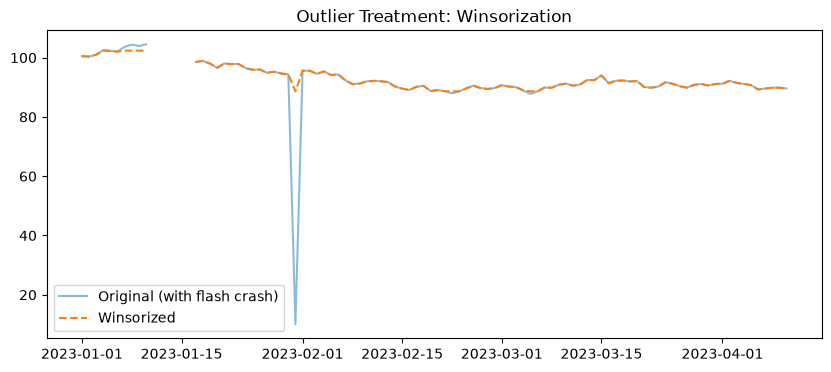

In [7]:
from scipy.stats import mstats

# Cap at the 5th and 95th percentiles for demonstration
# Note: mstats.winsorize modifies the array in-place, but returns it.
# We must drop NaNs first for scipy's winsorize, or use Pandas clip.
valid_prices = df['Stock_A_Price'].dropna()
lower_cap = valid_prices.quantile(0.05)
upper_cap = valid_prices.quantile(0.95)

df['Stock_A_Winsorized'] = df['Stock_A_Price'].clip(lower=lower_cap, upper=upper_cap)

plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Stock_A_Price'], label='Original (with flash crash)', alpha=0.5)
plt.plot(df['Date'], df['Stock_A_Winsorized'], label='Winsorized', linestyle='--')
plt.legend()
plt.title("Outlier Treatment: Winsorization")
plt.show()


## Part 2: Data Transformation (Week 4)
---
Once data is clean, it must be transformed into a numerical format that machine learning algorithms can easily digest.


### 2.1 Feature Scaling
Algorithms that compute distance (KNN, K-Means) or use Gradient Descent (Neural Networks, Logistic Regression) are highly sensitive to the scale of the features. If 'Income' ranges from $0 to $1,000,000 and 'Age' ranges from 0 to 100, the model will inherently prioritize Income simply because the numbers are larger.

#### Min-Max Scaling (Normalization)
Scales data to a fixed range, usually [0, 1].
$$ X_{norm} = rac{X - X_{min}}{X_{max} - X_{min}} $$


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
# Reshape is needed because scaler expects 2D array
df['Volume_MinMax'] = scaler_mm.fit_transform(df[['Volume']].fillna(df['Volume'].median()))

print("Min-Max Scaled Volume stats:")
print(df['Volume_MinMax'].describe())


Min-Max Scaled Volume stats:
count    100.000000
mean       0.524565
std        0.275419
min        0.000000
25%        0.316532
50%        0.539931
75%        0.764057
max        1.000000
Name: Volume_MinMax, dtype: float64


#### Standardization (Z-Score Scaling)
Centers the data around a mean of 0 and a standard deviation of 1. It does NOT bound the data to a specific range.
$$ X_{std} = rac{X - \mu}{\sigma} $$


In [9]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df['Volume_Std'] = scaler_std.fit_transform(df[['Volume']].fillna(df['Volume'].median()))

print("Standardized Volume stats:")
print(df['Volume_Std'].describe())


Standardized Volume stats:
count    1.000000e+02
mean     1.348921e-16
std      1.005038e+00
min     -1.914205e+00
25%     -7.591393e-01
50%      5.606935e-02
75%      8.739347e-01
max      1.734921e+00
Name: Volume_Std, dtype: float64


### 2.2 Encoding Categorical Variables
Machine learning models need numbers, not strings. We must convert categories into numerical representations.

#### Label Encoding
Assigns an integer to each category (e.g., Apple=0, Banana=1, Cherry=2).
**Danger:** Algorithms might misinterpret these integers as having an ordinal relationship (Cherry > Apple), which is false! Use only for ordinal data (e.g., Low=0, Medium=1, High=2).

#### One-Hot Encoding
Creates a binary column for each category.


In [10]:
# One-Hot Encoding the 'Sector' column
df_encoded = pd.get_dummies(df, columns=['Sector'], drop_first=False)
print("One-Hot Encoded DataFrame snippet:")
print(df_encoded[['Date', 'Sector_Energy', 'Sector_Finance', 'Sector_Tech']].head())


One-Hot Encoded DataFrame snippet:
        Date  Sector_Energy  Sector_Finance  Sector_Tech
0 2023-01-01          False            True        False
1 2023-01-02          False           False         True
2 2023-01-03           True           False        False
3 2023-01-04          False            True        False
4 2023-01-05           True           False        False


### 2.3 Handling Imbalanced Data
In finance, target variables are often highly imbalanced. For example, in Credit Default prediction, 98% of people pay their loans, and 2% default. If a model predicts "Will Pay" every time, it achieves 98% accuracy but is completely useless!

#### Synthetic Minority Over-sampling Technique (SMOTE)
SMOTE creates synthetic samples of the minority class by interpolating between existing minority instances using K-Nearest Neighbors.


In [11]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

# Create a highly imbalanced synthetic dataset
X_imb, y_imb = make_classification(n_samples=1000, n_features=5, weights=[0.95, 0.05], random_state=42)
print("Original class distribution:", Counter(y_imb))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imb, y_imb)
print("Resampled class distribution:", Counter(y_resampled))


Original class distribution: Counter({0: 944, 1: 56})
Resampled class distribution: Counter({0: 944, 1: 944})


## Part 3: Feature Selection (Week 5)
---
Adding too many features leads to the **Curse of Dimensionality**: models become complex, prone to overfitting, and slow to train. Feature selection helps us pick only the most predictive signals.


### 3.1 Filter Methods
Filter methods evaluate the relevance of features independently of any machine learning model, usually via statistical tests.

#### Pearson Correlation
Measures the linear correlation between features and the target variable.


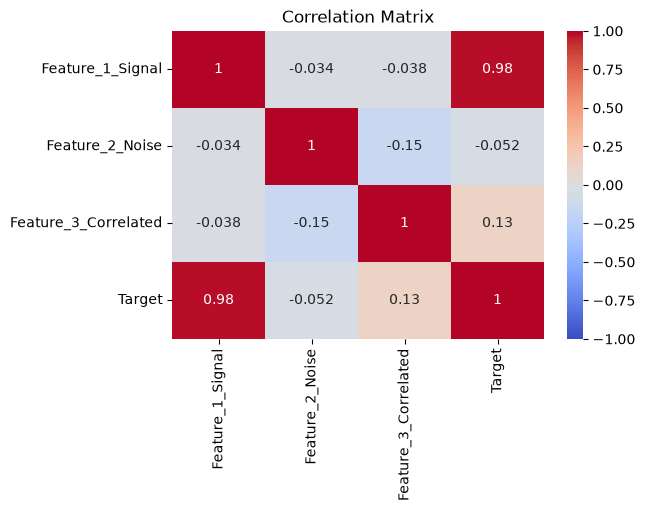

In [12]:
# Generate synthetic dataset for feature selection
np.random.seed(42)
X = pd.DataFrame({
    'Feature_1_Signal': np.random.rand(100),
    'Feature_2_Noise': np.random.rand(100),
    'Feature_3_Correlated': np.random.rand(100)
})
# Target is heavily dependent on Feature 1, slightly on 3, and not at all on 2
y = 3 * X['Feature_1_Signal'] + 0.5 * X['Feature_3_Correlated'] + np.random.randn(100)*0.1

X['Target'] = y
corr_matrix = X.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# Drop Target from X for next steps
X = X.drop('Target', axis=1)


### 3.2 Wrapper Methods
Wrapper methods use a predictive model to score feature subsets. They are computationally expensive but highly accurate.

#### Recursive Feature Elimination (RFE)
RFE starts with all features, builds a model, discards the least important feature based on model weights, and repeats.


In [13]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model = LinearRegression()
# Select the top 2 features
rfe = RFE(estimator=model, n_features_to_select=2)
rfe.fit(X, y)

print("RFE Feature Ranking (1 means selected):")
for feature, rank in zip(X.columns, rfe.ranking_):
    print(f"{feature}: {rank}")


RFE Feature Ranking (1 means selected):
Feature_1_Signal: 1
Feature_2_Noise: 2
Feature_3_Correlated: 1


### 3.3 Embedded Methods
Embedded methods perform feature selection automatically during the model training process.
* **Lasso (L1 Regularization):** Shrinks coefficients of useless features to exactly 0.
* **Tree-based Feature Importance:** Random Forests and XGBoost naturally measure how much each feature contributes to reducing impurity (Gini/Entropy).


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
for feature, imp in zip(X.columns, importances):
    print(f"{feature}: {imp:.4f}")
    
# Feature 1 dominates, as expected!


Feature_1_Signal: 0.9736
Feature_2_Noise: 0.0062
Feature_3_Correlated: 0.0202


---
## Part 4: Comprehensive Practice (Exercises)
---
> **Instructions:** The following exercises represent a realistic end-to-end Data Preparation pipeline for a Quantitative Risk Analyst. You will NOT be provided with the solution code. You must write it yourself based on the theory above.

### Case Study: Credit Risk Modeling
You are provided with a dataset `credit_risk_raw.csv` containing historical loan applications.

### Task 1: Data Cleaning
1. Identify all columns containing missing values.
2. For the `Annual_Income` column, impute missing values using the **Median** to avoid the influence of extreme wealthy outliers.
3. For the `Employment_Length` categorical column, impute missing values using the **Mode**.
4. The `Debt_To_Income` ratio contains extreme outliers (e.g., 999% due to data entry errors). Use the **IQR Method** to identify these and **Winsorize** them at the 99th percentile.

### YOUR CODE HERE ###


In [15]:
# YOUR CODE HERE


### Task 2: Data Transformation
1. The `Loan_Status` column contains "Approved" and "Rejected". Use **Label Encoding** to convert this to 1 and 0.
2. The `Home_Ownership` column has 4 categories (RENT, OWN, MORTGAGE, OTHER). Apply **One-Hot Encoding** to this column.
3. Scale the `Annual_Income`, `Loan_Amount`, and `Credit_Score` columns using **StandardScaler**.

### YOUR CODE HERE ###


In [16]:
# YOUR CODE HERE


### Task 3: Feature Selection & Imbalance
1. The dataset is imbalanced (85% Approved, 15% Rejected). Separate your features (X) and target (y), and apply **SMOTE** to balance the training set.
2. Train a `RandomForestClassifier` on the balanced dataset and plot the **Feature Importances** as a bar chart. Which 3 features are the most critical for determining loan approval?

### YOUR CODE HERE ###


In [17]:
# YOUR CODE HERE
